# Interest-area / stimulus-text alignment — `todo.md` T3.18

**Question this notebook answers:** does `know_qa_dataprep.check_text_alignment` catch a real
problem, or is it firing on something else?

`check_text_alignment` exists to catch a stored-text bug: a displaced double quote adds a
token the display never showed, which shifts every interest-area boundary after it by one
word, so each screen area's eye-movement measures pick up a word belonging to its neighbour.
Diana was not certain that bug was real (2026-09-05).

### Conclusions, up front

1. **The guard excludes nothing.** It is called with a hardcoded `strict=False` and its return
   value is discarded — it prints and moves on. There is no silent exclusion to fix. (§1)
2. **The bug is real.** It fires on 1 of 154 KnowQA trials, and that trial is literally the
   docstring's example. 4 of its 38 interest areas are assigned to the wrong screen area, and
   nothing is flagged `unknown`. (§2–3)
3. **`add_IA_screen_location` is not itself wrong** — it derives area membership by *counting
   words in the stored text*, which is correct whenever the stored text matches what was
   rendered. The bug is in its input. (§3)
4. **L1 is never checked, and has 20 misaligned trials of its own — from two different
   causes**, one of which (a whole-trial area reorder) is worse than the KnowQA case. (§5–6)
5. **Every misaligned trial in every dataset is drawn in §7** — 27 of them, in three modes.
6. **The extra token comes from the presentation software, not this repo**, and the at-risk set
   is knowable in advance: exactly 12 of 978 stimulus rows. (§8)

### Scope

Investigation only. **Nothing here changes the pipeline, the data, or any saved result.** It
writes its own tables and figures to `reports/{report_data,plots}/text_alignment/` and touches
nothing under `papers/`.

**Run from the repository root** (`docs/conventions.md`). Reading all of L1 takes a few
minutes — see §5.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repo root without a "../" literal, so the notebook runs from either
# the repo root (the agreed convention) or from notebooks/.
ROOT = Path.cwd()
while not (ROOT / "src" / "data_paths.py").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Run this notebook from inside the QA_eyetracking_workspace repo.")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.constants as Con
import src.data_paths as P
from src.viz.plot_output import save_df_csv, save_plot

# Every table and figure below lands under this one topic name, so the
# reports/plots/<topic> and reports/report_data/<topic> folders match (todo T4.0).
REL_DIR = "text_alignment"
TRIAL_REL_DIR = f"{REL_DIR}/trials"
SAVE = True

# The five screen areas, in interest-area reading order: question, then the four
# answers by screen position. This is the order add_IA_screen_location assumes.
TEXT_COLS = ("question", "answer_1", "answer_2", "answer_3", "answer_4")

print("repo root:", ROOT)
print("pandas", pd.__version__)

repo root: e:\Technion\QA PROJECT\programming\QA_eyetracking_workspace
pandas 3.0.1


---
## 1. What the guard does with the trials it flags

`todo.md` T3.18 asks this explicitly, because a guard that *excludes* flagged trials would be a
silent-exclusion violation of `docs/conventions.md` regardless of how the investigation lands.

In [2]:
src_path = ROOT / "src" / "data_prep" / "know_qa_dataprep.py"
lines = src_path.read_text(encoding="utf-8").splitlines()

for i, l in enumerate(lines, start=1):
    if "check_text_alignment(" in l and "def " not in l:
        print(f"{src_path.name}:{i}: {l.strip()}")

import inspect
from src.data_prep.know_qa_dataprep import check_text_alignment
print()
print("signature:", inspect.signature(check_text_alignment))

know_qa_dataprep.py:825: check_text_alignment(frames[IA_REPORT_NAME], strict=False, verbose=verbose)

signature: (ia_df: 'pd.DataFrame', strict: 'bool' = False, verbose: 'bool' = True) -> 'pd.DataFrame'


The single call site passes **`strict=False` as a hardcoded literal** — the pipeline's own
`strict` flag (from `--lenient`) is deliberately *not* threaded in — and the return value is
not bound to anything.

So the guard **prints a warning and nothing else**: it never raises, never filters, never
alters a downstream frame. T3.18's concern about silent exclusion does not apply.

---
## 2. Run the guard on KnowQA

Straight from the cleaned report the pipeline itself reads.

In [3]:
knowqa = pd.read_csv(P.KNOW_QA_CLEANED_DIR / "IA_answers.csv", low_memory=False)
print(f"{len(knowqa):,} interest-area rows")

flagged = check_text_alignment(knowqa, strict=False, verbose=True)
flagged

5,920 interest-area rows
  text alignment: 153/154 trials line up word-for-word with the stimulus text
session_id  trial_number text_id_with_q  n_interest_areas  n_expected_tokens  first_mismatch_at             on_screen           expected
   4000_31            31    3_7_Adv_5_0                38                 39                  7 word "cool"? It comes word "cool" "?" It


,session_id,trial_number,text_id_with_q,n_interest_areas,n_expected_tokens,first_mismatch_at,on_screen,expected
0,4000_31,31,3_7_Adv_5_0,38,39,7,"word ""cool""? It comes","word ""cool"" ""?"" It"


One trial in 154. The stored question carries **9** tokens where the screen showed **8**
interest areas — `"cool" "?"` in the stored text against `"cool"?` on screen.

That is the exact example in the guard's own docstring, so the docstring was written from this
trial rather than from a hypothetical.

---
## 3. The mechanism, and what it costs

`data_csv_generation.add_IA_screen_location` assigns each interest area to a screen area by
**cumulative token counts of the stored text** — it never looks at where a word actually sits
on screen:

```python
q_end      = q_len - 1
first_end  = q_len + first_len - 1
second_end = q_len + first_len + second_len - 1
...
index_id   = group[C.INTEREST_AREA_ID] - 1
```

That is a reasonable design, and correct on 19,416 of 19,436 L1 trials. But it makes area
membership entirely dependent on the stored text matching what was rendered — so one phantom
token silently moves every boundary after it.

In [4]:
SESSION, TRIAL = "4000_31", 31
trial = (
    knowqa[(knowqa[Con.SESSION_ID] == SESSION) & (knowqa[Con.TRIAL_NUMBER] == TRIAL)]
    .sort_values(Con.INTEREST_AREA_ID)
)
first = trial.iloc[0]

print("item:", first[Con.TEXT_ID_WITH_Q_COLUMN], "\n")
for c in TEXT_COLS:
    toks = str(first[c]).split()
    print(f"  {c:9s} n={len(toks):2d}  {first[c]!r}")

words = [str(w) for w in trial[Con.IA_LABEL]]
print(f"\n  interest areas on screen: {len(words)}")
print("  ", " | ".join(words))

item: 3_7_Adv_5_0 

  question  n= 9  'What is true of the English word "cool" "?"'
  answer_1  n= 7  'It comes from the French word "chouette"'
  answer_2  n= 8  'French television ads for refrigerators often use it'
  answer_3  n=10  'It started being used in France in the 20th century'
  answer_4  n= 5  'Carle used to use it'

  interest areas on screen: 38
   What | is | true | of | the | English | word | "cool"? | It | comes | from | the | French | word | "chouette" | French | television | ads | for | refrigerators | often | use | it | It | started | being | used | in | France | in | the | 20th | century | Carle | used | to | use | it


### Recovering what the true areas were

To say *how wrong* an assignment is, we need the true one. The three helpers below do that for
any misaligned trial, and §7 reuses them for all 27.

`true_areas` names the failure mode it found, because there turn out to be three, and they are
not equally serious:

| mode | what happened | consequence |
|---|---|---|
| **merged** | two stored tokens were rendered as one word | every boundary after it slides one word later |
| **truncated** | the last word never got an interest area | no boundary moves; the last area is one word short |
| **reordered** | the blocks appeared on screen in a different order | the whole trial's area mapping is wrong |

In [5]:
def stored_blocks(head):
    '''The five stored text blocks for one trial, in the order the pipeline assumes.'''
    return [(area, str(head[c]).split()) for area, c in zip(Con.LOC_CHOICES, TEXT_COLS)]


def _areas_from_lengths(lengths, names, n):
    '''Expand per-area token counts into a per-interest-area label array.'''
    ends = np.cumsum(lengths) - 1
    idx = np.arange(n)
    conds = [idx <= ends[0]] + [(idx > ends[i - 1]) & (idx <= ends[i]) for i in range(1, 5)]
    return np.select(conds, names, default="unknown")


def assigned_areas(blocks, n):
    '''What add_IA_screen_location assigns, reproduced from the stored token counts.'''
    return _areas_from_lengths([len(t) for _, t in blocks], [a for a, _ in blocks], n)


def true_areas(words, blocks):
    '''Recover each interest area's real screen area, and name the failure mode.

    The interest areas themselves are ground truth for what was displayed, so the true
    segmentation is recovered by reconciling them against the five stored blocks.
    '''
    names = [a for a, _ in blocks]
    lengths = [len(t) for _, t in blocks]
    flat = [t for _, toks in blocks for t in toks]
    n, m = len(words), len(flat)

    if n == m:
        # Same tokens, different on-screen order: find each stored block as a contiguous run.
        areas, pos, remaining = [], 0, list(range(5))
        while pos < n:
            for bi in list(remaining):
                toks = blocks[bi][1]
                if words[pos:pos + len(toks)] == toks:
                    areas += [names[bi]] * len(toks)
                    pos += len(toks)
                    remaining.remove(bi)
                    break
            else:
                raise ValueError("cannot segment the on-screen words into the five stored blocks")
        assert not remaining, "not every stored block was placed"
        return np.array(areas), "reordered"

    if m != n + 1:
        raise ValueError(f"unhandled shape: {n} interest areas vs {m} stored tokens")

    slip = next((i for i, (a, b) in enumerate(zip(words, flat)) if a != b), n)
    true_len = list(lengths)
    if slip == n:
        # The sequences agree everywhere they overlap; the stored text simply has one
        # more token at the end, so the final area lost its last word.
        true_len[-1] -= 1
        mode = "truncated"
    else:
        # Two stored tokens were rendered as one word. The block holding the first of
        # them is the one that is a word shorter than the stored text claims.
        block_of = np.repeat(np.arange(5), lengths)
        true_len[block_of[slip]] -= 1
        mode = "merged"
    assert sum(true_len) == n, "recovered lengths do not cover the interest areas"
    return _areas_from_lengths(true_len, names, n), mode

In [6]:
blocks = stored_blocks(first)
assigned = assigned_areas(blocks, len(words))
truth, mode = true_areas(words, blocks)

comparison = pd.DataFrame({
    "IA_ID": trial[Con.INTEREST_AREA_ID].to_numpy(),
    "word": words,
    "assigned": assigned,
    "true": truth,
})
comparison["misassigned"] = comparison.assigned != comparison["true"]

print("failure mode:", mode)
print(f"stored token counts : {[len(t) for _, t in blocks]}  total={sum(len(t) for _, t in blocks)}")
print(f"interest areas      : {len(words)}")
print()
print(f"misassigned interest areas : {int(comparison.misassigned.sum())} of {len(comparison)}")
print(f"any IA falling to 'unknown': {'unknown' in set(assigned)}")
comparison[comparison.misassigned]

failure mode: merged
stored token counts : [9, 7, 8, 10, 5]  total=39
interest areas      : 38

misassigned interest areas : 4 of 38
any IA falling to 'unknown': False


,IA_ID,word,assigned,true,misassigned
8,9,It,question,answer_0(top),True
15,16,French,answer_0(top),answer_1(left),True
23,24,It,answer_1(left),answer_2(right),True
33,34,Carle,answer_2(right),answer_3(bottom),True


**Four interest areas land in the wrong screen area, and none of them is flagged.** Each is the
*first word of an answer*, counted as part of the area before it — the four internal boundaries
have each moved one word later. The bottom answer loses `Carle` and gains nothing, so it ends
with 4 words instead of 5.

`np.select`'s `default="unknown"` never fires, because the inflated final boundary still lies
past the last interest area. That silence is why the guard had to be written at all.

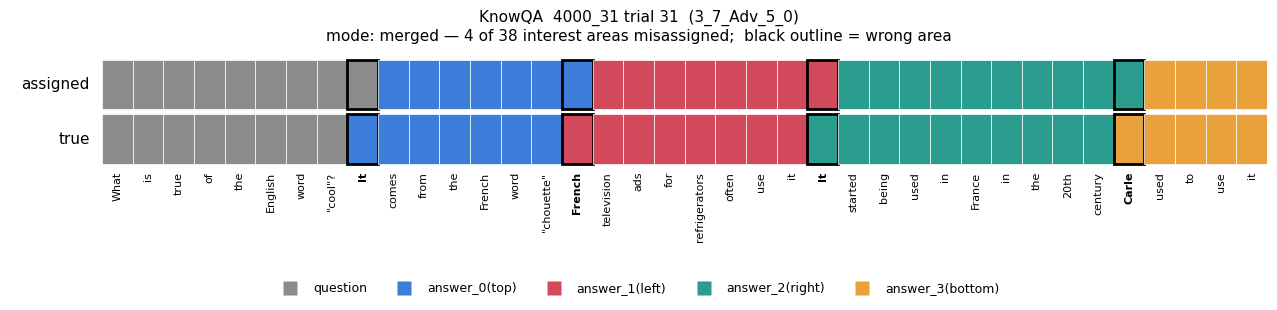

In [7]:
AREA_COLORS = dict(zip(Con.LOC_CHOICES, ["#8c8c8c", "#3b7dd8", "#d1495b", "#2a9d8f", "#e9a13b"]))


def plot_alignment(words, assigned, truth, title, subtitle, filename=None,
                   rel_dir=None, dpi=150):
    '''One row of colour per interest area: what the pipeline assigned, and what was true.'''
    mis = np.asarray(assigned) != np.asarray(truth)
    width = max(7.0, 0.34 * len(words))
    fig, ax = plt.subplots(figsize=(width, 3.2))

    for row, (lab, series) in enumerate([("assigned", assigned), ("true", truth)]):
        y = 1 - row
        for i, area in enumerate(series):
            ax.add_patch(plt.Rectangle(
                (i, y), 1, 0.9, facecolor=AREA_COLORS.get(area, "#000000"),
                edgecolor="black" if mis[i] else "white", linewidth=2.0 if mis[i] else 0.5,
            ))
        ax.text(-0.4, y + 0.45, lab, ha="right", va="center", fontsize=11)

    for i, w in enumerate(words):
        ax.text(i + 0.5, -0.15, w, rotation=90, ha="center", va="top", fontsize=8,
                fontweight="bold" if mis[i] else "normal")

    longest = max(len(w) for w in words)
    ax.set_xlim(-3, len(words))
    ax.set_ylim(-(1.0 + 0.11 * longest), 2.1)
    ax.axis("off")
    ax.set_title(f"{title}\n{subtitle}", fontsize=11)
    ax.legend(
        handles=[plt.Line2D([], [], marker="s", linestyle="", markersize=10,
                            markerfacecolor=c, markeredgecolor="none", label=a)
                 for a, c in AREA_COLORS.items()],
        loc="lower center", bbox_to_anchor=(0.5, -0.04), ncol=5, frameon=False, fontsize=9,
    )
    plt.tight_layout()
    if SAVE and filename:
        save_plot(fig, rel_dir=rel_dir or TRIAL_REL_DIR, filename=filename, dpi=dpi)
    plt.show()
    return int(mis.sum())


_ = plot_alignment(
    words, assigned, truth,
    f"KnowQA  {SESSION} trial {TRIAL}  ({first[Con.TEXT_ID_WITH_Q_COLUMN]})",
    f"mode: {mode} — {int(comparison.misassigned.sum())} of {len(words)} interest areas "
    "misassigned;  black outline = wrong area",
    filename="knowqa_misassigned_trial", rel_dir=REL_DIR,
)

---
## 4. The same check, pointed at any dataset

The shipped guard groups by `session_id` / `trial_number`, which only KnowQA has — so it
**cannot be run on L1 or on the pilots as written**, even though they carry every column it
needs (`IA_LABEL`, `question`, `answer_1..4`).

Below is the guard's logic with the trial key as a parameter. It also records whether the first
divergence is at the **tail** (the sequences agree everywhere they overlap) or **mid-sequence**,
because those are different problems with very different severity.

In [8]:
def alignment_report(ia_df, trial_keys, label=""):
    '''Faithful re-implementation of check_text_alignment, parameterized on the trial key.

    Returns one row per misaligned trial. `tail_only` is True when the two sequences agree
    on every position they share, i.e. one simply ran out first -- in that case no area
    boundary before the end can have moved.
    '''
    missing = [c for c in TEXT_COLS if c not in ia_df.columns]
    assert not missing, f"{label}: stimulus text columns absent: {missing}"
    assert Con.IA_LABEL in ia_df.columns, f"{label}: {Con.IA_LABEL} absent"
    for k in trial_keys:
        assert k in ia_df.columns, f"{label}: trial key {k!r} absent"

    ordered = ia_df.sort_values(list(trial_keys) + [Con.INTEREST_AREA_ID])
    grouped = ordered.groupby(list(trial_keys), sort=False)

    rows = []
    for key, g in grouped:
        on_screen = [str(x) for x in g[Con.IA_LABEL]]
        head = g.iloc[0]
        expected = []
        for c in TEXT_COLS:
            expected += str(head[c]).split()
        if on_screen == expected:
            continue
        overlap = min(len(on_screen), len(expected))
        slip = next((i for i, (a, b) in enumerate(zip(on_screen, expected)) if a != b), overlap)
        rows.append({
            "dataset": label,
            "trial": " / ".join(str(k) for k in (key if isinstance(key, tuple) else (key,))),
            "item": head.get(Con.TEXT_ID_WITH_Q_COLUMN),
            "n_interest_areas": len(on_screen),
            "n_expected_tokens": len(expected),
            "first_mismatch_at": slip,
            "tail_only": slip == overlap,
            "on_screen": " ".join(on_screen[max(slip - 1, 0):slip + 3]),
            "expected": " ".join(expected[max(slip - 1, 0):slip + 3]),
        })

    out = pd.DataFrame(rows)
    n_trials = grouped.ngroups
    print(f"  {label:12s} {n_trials - len(out):>6,}/{n_trials:<6,} trials aligned"
          f"   misaligned={len(out)}")
    return out, n_trials

---
## 5. All four datasets

The two pilots are cleaned by `experiment_builder/data_prep_new_exp.ipynb`, which never calls
the guard at all; L1 goes straight into `data_csv_generation.main()`, which also never calls it.
**KnowQA is the only dataset that has ever been checked.**

Reading L1 is the slow step: `all_participants.csv` is ~3.2 GB, so only the eleven columns this
analysis needs are streamed. The frames are kept, because §7 draws every flagged trial.

In [9]:
frames, results, totals = {}, [], {}

for label, path, keys in [
    ("KnowQA",      P.KNOW_QA_CLEANED_DIR / "IA_answers.csv",     (Con.SESSION_ID, Con.TRIAL_NUMBER)),
    ("second_test", P.SECOND_TEST_CLEANED_DIR / "IA_answers.csv", (Con.PARTICIPANT_ID, Con.TRIAL_ID)),
    ("testrun_QA",  P.NEW_EXP_CLEANED_DIR / "IA_answers.csv",     (Con.PARTICIPANT_ID, Con.TRIAL_ID)),
]:
    assert path.exists(), f"{label}: {path} not found -- build the run first (docs/data-pipeline.md §2)"
    df = pd.read_csv(path, low_memory=False)
    out, n = alignment_report(df, keys, label)
    frames[label] = (df, keys)
    results.append(out)
    totals[label] = n

  KnowQA          153/154    trials aligned   misaligned=1
  second_test     355/361    trials aligned   misaligned=6
  testrun_QA       45/45     trials aligned   misaligned=0


In [10]:
L1_COLS = [Con.PARTICIPANT_ID, Con.TRIAL_ID, Con.INTEREST_AREA_ID, Con.IA_LABEL,
           *TEXT_COLS, Con.TEXT_ID_WITH_Q_COLUMN, Con.ANSWERS_ORDER_COLUMN]

assert P.ALL_PARTICIPANTS_PROCESSED_PATH.exists(), (
    f"{P.ALL_PARTICIPANTS_PROCESSED_PATH} not found -- run "
    "src.data_prep.data_csv_generation.main() first (docs/data-pipeline.md §3)"
)

# ~3.2 GB on disk; a few minutes.
l1 = pd.concat(
    pd.read_csv(P.ALL_PARTICIPANTS_PROCESSED_PATH, usecols=L1_COLS,
                dtype={Con.PARTICIPANT_ID: str}, chunksize=2_000_000, low_memory=False),
    ignore_index=True,
)
print(f"L1: {len(l1):,} interest-area rows")

L1_KEYS = (Con.PARTICIPANT_ID, Con.TRIAL_ID)
l1_bad, l1_n = alignment_report(l1, L1_KEYS, "L1")
frames["L1"] = (l1, L1_KEYS)
results.append(l1_bad)
totals["L1"] = l1_n

L1: 760,628 interest-area rows
  L1           19,416/19,436 trials aligned   misaligned=20


In [11]:
misaligned = pd.concat(results, ignore_index=True)

summary = (
    misaligned.groupby("dataset")
    .agg(misaligned=("trial", "size"),
         tail_only=("tail_only", "sum"),
         mid_sequence=("tail_only", lambda s: int((~s).sum())))
    .reindex(list(totals))
    .fillna(0).astype(int)
)
summary.insert(0, "trials", pd.Series(totals))
summary["pct"] = (100 * summary.misaligned / summary.trials).round(2)
summary

,trials,misaligned,tail_only,mid_sequence,pct
dataset,,,,,
KnowQA,154,1,0,1,0.65
second_test,361,6,0,6,1.66
testrun_QA,45,0,0,0,0.00
L1,19436,20,10,10,0.10


**KnowQA is the only dataset anyone has been looking at, and it is the least affected.**
`second_test` has six, and L1 — the paper's dataset — has twenty.

['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\plots\\text_alignment\\misaligned_by_dataset.png']


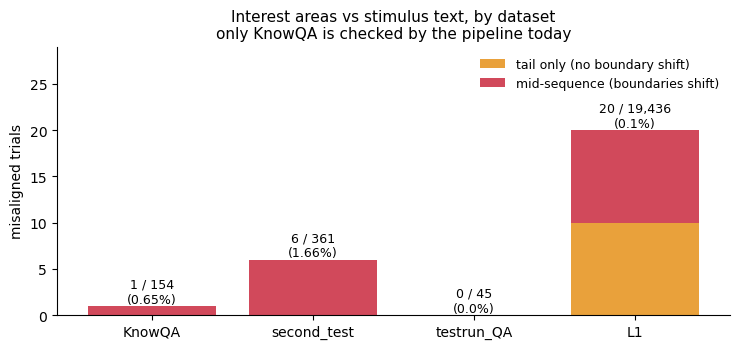

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
order = summary.index.tolist()
ax.bar(order, summary.tail_only, color="#e9a13b", label="tail only (no boundary shift)")
ax.bar(order, summary.mid_sequence, bottom=summary.tail_only, color="#d1495b",
       label="mid-sequence (boundaries shift)")
for i, k in enumerate(order):
    ax.text(i, summary.misaligned[k] + 0.35,
            f"{summary.misaligned[k]} / {summary.trials[k]:,}\n({summary.pct[k]}%)",
            ha="center", fontsize=9)
ax.set_ylabel("misaligned trials")
ax.set_title("Interest areas vs stimulus text, by dataset\n"
             "only KnowQA is checked by the pipeline today", fontsize=11)
ax.set_ylim(0, summary.misaligned.max() * 1.45)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
if SAVE:
    print(save_plot(fig, rel_dir=REL_DIR, filename="misaligned_by_dataset"))
plt.show()

---
## 6. L1's twenty trials are **not** the quote bug

They split cleanly into two causes, neither of which is the displaced quote. This is why
T3.18's proposed test — *compare the flagged trial's interest-area count against the same
question in L1* — would not have settled anything: L1's own copies are broken too, differently,
and in the KnowQA case it is the stored text that has the extra token, not the interest areas.

In [13]:
l1_bad.groupby(["item", "tail_only"]).size().rename("trials").reset_index()

,item,tail_only,trials
0,1_6_Adv_2_1,True,8
1,1_6_Ele_2_1,True,2
2,3_5_Adv_4_1,False,8
3,3_5_Ele_3_2,False,2


### 6a. Tail truncation — benign

Item `1_6_*_2_1`. The bottom answer is *"Since the time of the hunter-gatherers, immune systems
have been dependent on a healthy diet"* (15 words), but the interest areas stop at `healthy`:
the final word never got one. Because the divergence is at the very end, **every earlier
boundary is still correct** — only the bottom answer's word count is one short.

It is fully deterministic: it fires exactly when the 15-word answer lands in **screen slot 4**
(the bottom of the diamond, and therefore the last interest area on the screen).

In [14]:
def longest_answer_slot(row):
    return 1 + int(np.argmax([len(str(row[c]).split()) for c in TEXT_COLS[1:]]))


bad_trials = set(l1_bad.trial)
trials = l1.drop_duplicates([Con.PARTICIPANT_ID, Con.TRIAL_ID]).copy()
trials["trial"] = trials[Con.PARTICIPANT_ID] + " / " + trials[Con.TRIAL_ID].astype(str)
trials["misaligned"] = trials.trial.isin(bad_trials)

fam = trials[trials[Con.TEXT_ID_WITH_Q_COLUMN].isin(["1_6_Adv_2_1", "1_6_Ele_2_1"])].copy()
fam["longest_answer_in_slot"] = fam.apply(longest_answer_slot, axis=1)
trigger = pd.crosstab(fam.longest_answer_in_slot, fam.misaligned)
trigger

misaligned,False,True
longest_answer_in_slot,,
1,12,0
2,10,0
3,8,0
4,0,10


No exceptions in either direction, across all 40 trials of that item. Consistent with the last
word overflowing the rendered answer box.

### 6b. Reorder — worse than the KnowQA case

Item `3_5_*`. Here an **answer is rendered before the question**, so the whole trial's area
mapping is wrong — not shifted by one word, but structurally misaligned. It clusters by **list
group**, and is *not* explained by `answers_order`: two list groups share the same order and
land on opposite sides.

In [15]:
scramble = l1_bad[~l1_bad.tail_only].iloc[0]
# NB: scramble["item"], not scramble.item -- the latter is the pandas Series method.
same_item = trials[trials[Con.TEXT_ID_WITH_Q_COLUMN] == scramble["item"]].copy()
same_item["list_group"] = same_item[Con.PARTICIPANT_ID].str.split("_").str[0]
(same_item.groupby(["list_group", Con.ANSWERS_ORDER_COLUMN])["misaligned"]
          .agg(trials="size", misaligned="sum")
          .sort_values("misaligned", ascending=False))

,,trials,misaligned
list_group,answers_order,,
l11,"['A', 'C', 'B', 'D']",2,2
l35,"['D', 'A', 'C', 'B']",2,2
l5,"['B', 'A', 'C', 'D']",2,2
l47,"['D', 'A', 'B', 'C']",2,2
l17,"['A', 'C', 'B', 'D']",2,0
l23,"['B', 'A', 'D', 'C']",2,0
l41,"['B', 'A', 'D', 'C']",2,0
l29,"['A', 'D', 'C', 'B']",2,0
l53,"['D', 'C', 'A', 'B']",2,0


---
## 7. Every misaligned trial, drawn

All 27, in the three modes. Each figure shows one row of colour per interest area — what
`add_IA_screen_location` **assigned**, against what was **true** — with a black outline on every
interest area whose area label is wrong.

Note the redundancy: 27 trials but only seven distinct (item, mode) situations, because the same
stimulus breaks the same way for every participant who saw it.

In [16]:
def trial_rows(label, trial_id):
    '''Fetch one trial's interest areas from its dataset frame, in interest-area order.'''
    df, keys = frames[label]
    sel = pd.Series(True, index=df.index)
    for k, v in zip(keys, trial_id.split(" / ")):
        sel &= df[k].astype(str) == v
    return df[sel].sort_values(Con.INTEREST_AREA_ID)


def safe_name(s):
    return re.sub(r"[^0-9A-Za-z]+", "_", s).strip("_")


gallery = []
for _, row in misaligned.iterrows():
    g = trial_rows(row.dataset, row.trial)
    assert len(g), f"{row.dataset} {row.trial}: no rows found"
    w = [str(x) for x in g[Con.IA_LABEL]]
    b = stored_blocks(g.iloc[0])
    a = assigned_areas(b, len(w))
    t, m = true_areas(w, b)
    gallery.append({
        "dataset": row.dataset, "trial": row.trial, "item": row["item"], "mode": m,
        "n_interest_areas": len(w), "n_misassigned": int((a != t).sum()),
        "words": w, "assigned": a, "true": t,
    })

per_trial = pd.DataFrame([{k: v for k, v in d.items()
                           if k not in ("words", "assigned", "true")} for d in gallery])
print(per_trial.groupby(["mode", "dataset"]).agg(
    trials=("trial", "size"),
    interest_areas_misassigned=("n_misassigned", "sum")).to_string())
per_trial

                       trials  interest_areas_misassigned
mode      dataset                                        
merged    KnowQA            1                           4
          second_test       6                          24
reordered L1               10                          54
truncated L1               10                           0


,dataset,trial,item,mode,n_interest_areas,n_misassigned
0,KnowQA,4000_31 / 31,3_7_Adv_5_0,merged,38,4
1,second_test,r4_l16_2 / 5,2_1_Adv_4_1,merged,43,4
2,second_test,r5_l9_b3 / 32,2_1_Adv_4_1,merged,43,4
3,second_test,r6_12_b3 / 18,3_9_Adv_1_2,merged,32,4
4,second_test,r6_12_b3 / 43,3_6_Adv_7_2,merged,40,4
5,second_test,y7_12_b3 / 25,3_9_Adv_1_2,merged,32,4
6,second_test,y7_12_b3 / 46,3_6_Adv_7_2,merged,40,4
7,L1,l11_342 / 45,3_5_Adv_4_1,reordered,15,6
8,L1,l11_344 / 41,3_5_Adv_4_1,reordered,15,6
9,L1,l17_355 / 14,3_5_Ele_3_2,reordered,24,4


Note what the counts say, and read them as *proportions* — the reordered trials are short:

| mode | interest areas misassigned | as a share of the trial |
|---|---|---|
| `reordered` | 4–7 of 15–24 | **27–47%** |
| `merged` | exactly 4 of 32–43 | 9–13% |
| `truncated` | **0** | 0% — no word changes area at all |

`merged` always misassigns exactly four, because there are exactly four internal boundaries and
each moves one word. `truncated` changes no label at all; it only leaves the bottom answer a
word short.

### 7a. `merged` — two stored tokens rendered as one word

KnowQA and `second_test`. Every boundary after the merge slides one word later, so the first
word of each answer is counted as part of the area before it.

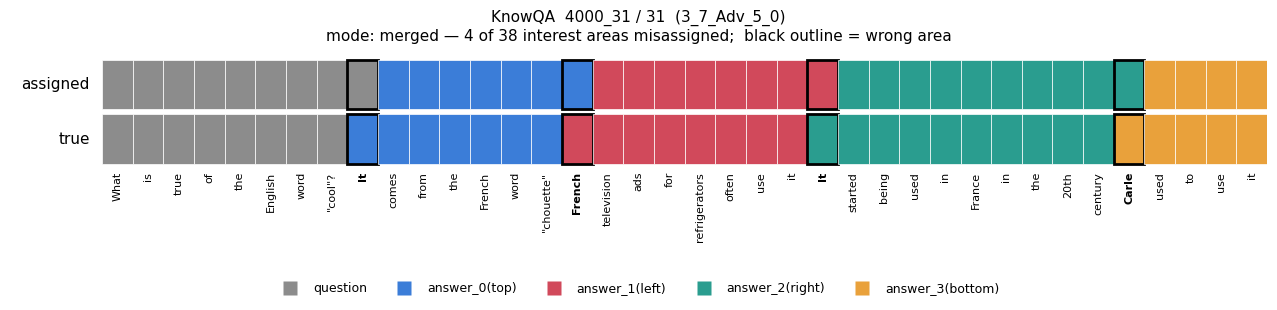

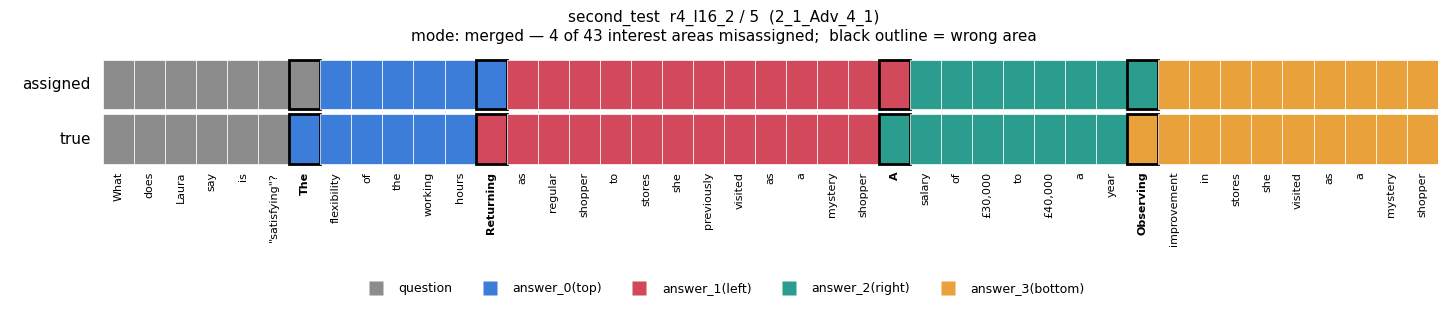

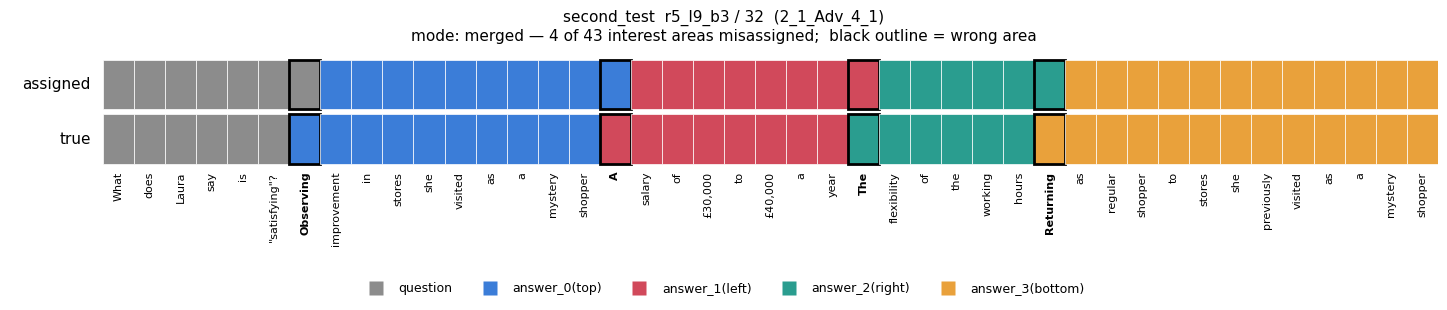

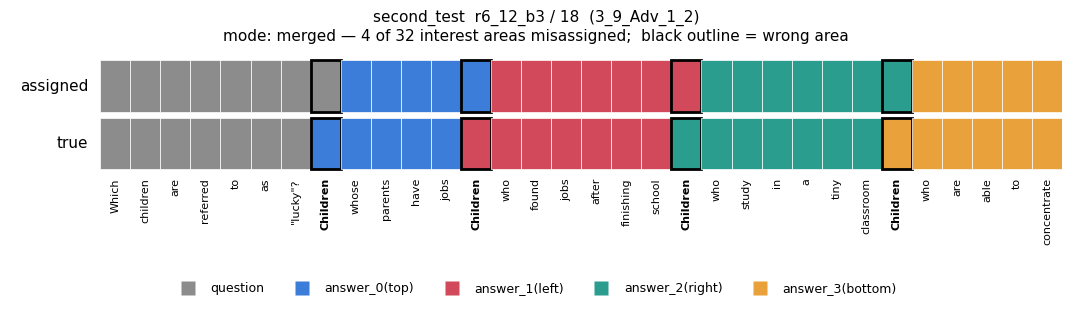

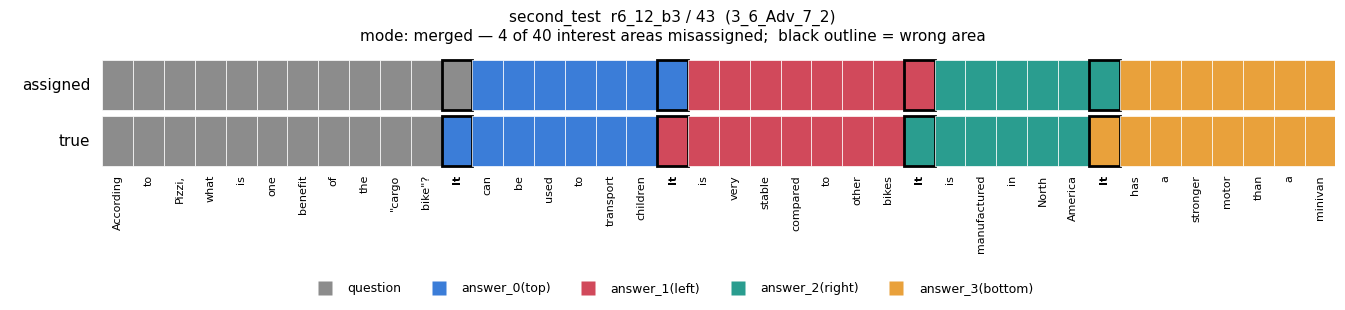

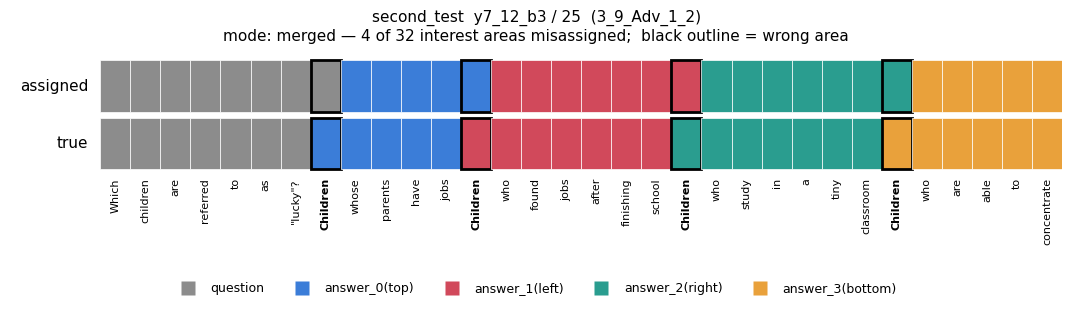

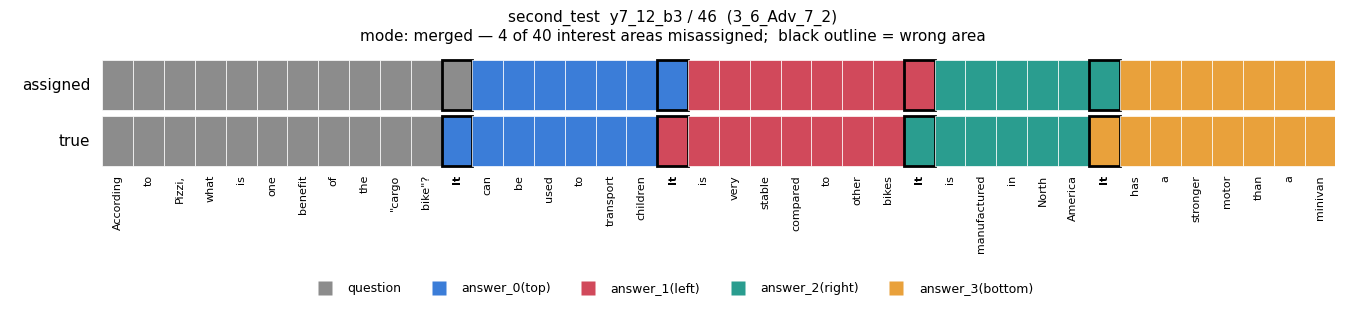

In [17]:
for d in [d for d in gallery if d["mode"] == "merged"]:
    plot_alignment(
        d["words"], d["assigned"], d["true"],
        f'{d["dataset"]}  {d["trial"]}  ({d["item"]})',
        f'mode: merged — {d["n_misassigned"]} of {d["n_interest_areas"]} interest areas '
        "misassigned;  black outline = wrong area",
        filename=safe_name(f'{d["dataset"]}__{d["trial"]}'),
    )

### 7b. `truncated` — the last word never got an interest area

L1, item `1_6_*_2_1`. The two rows are identical: **no word changes area.** The only damage is
that the bottom answer is measured over 14 words instead of 15, so its `skip_rate` denominator
and every per-word mean are computed over one word too few.

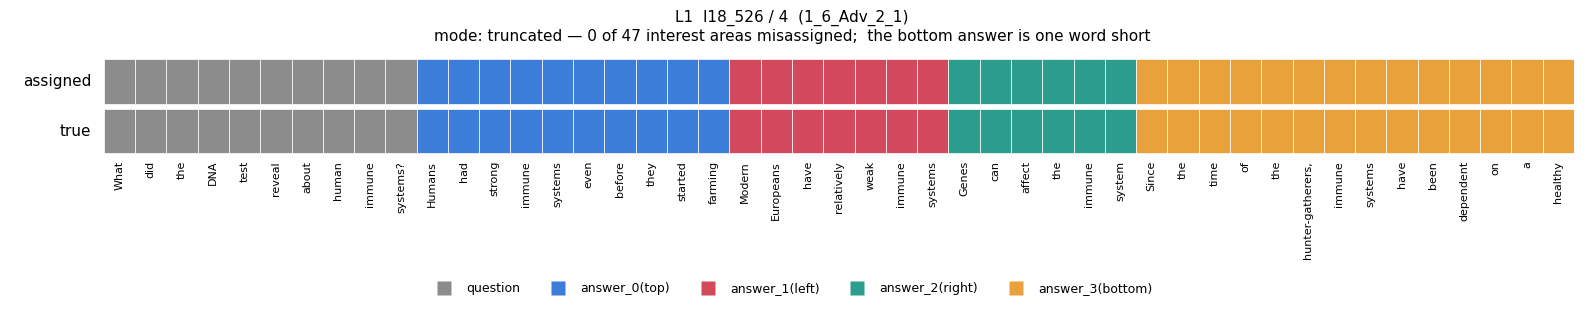

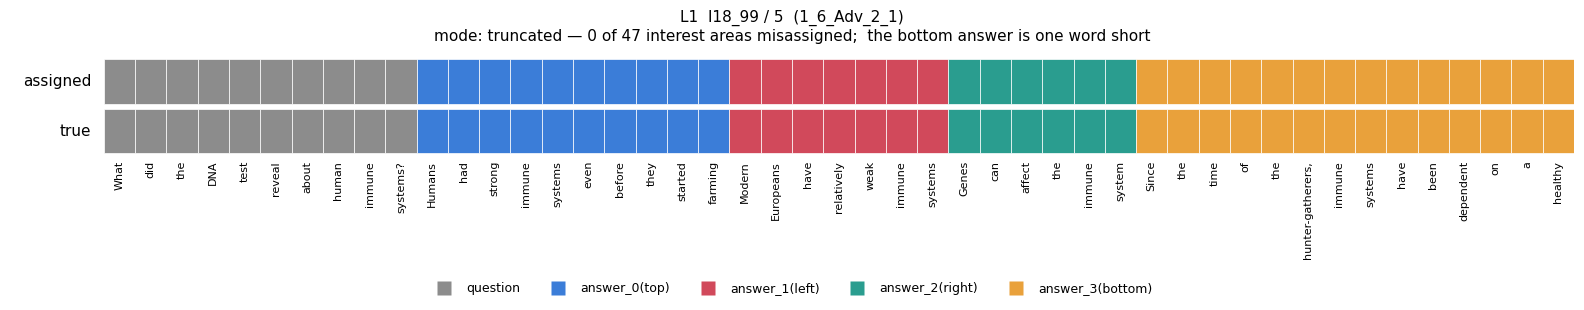

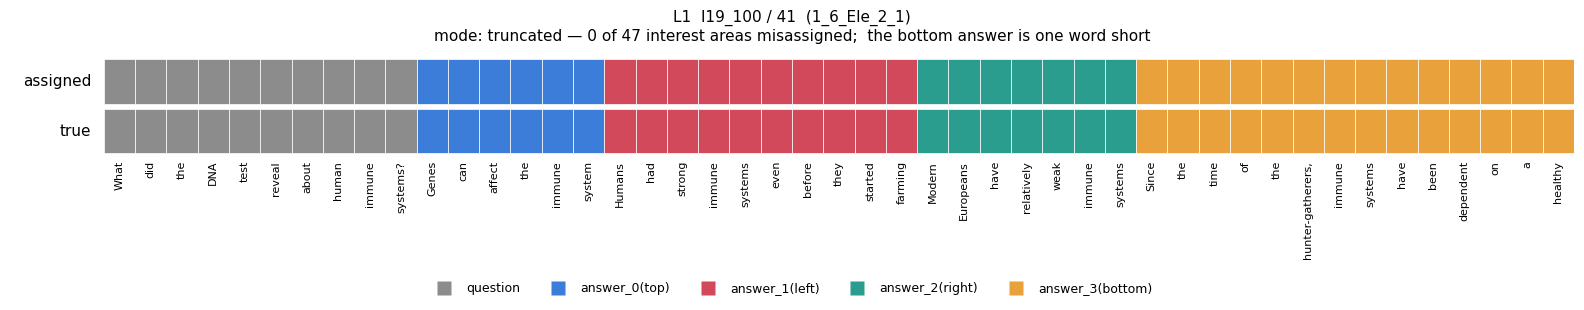

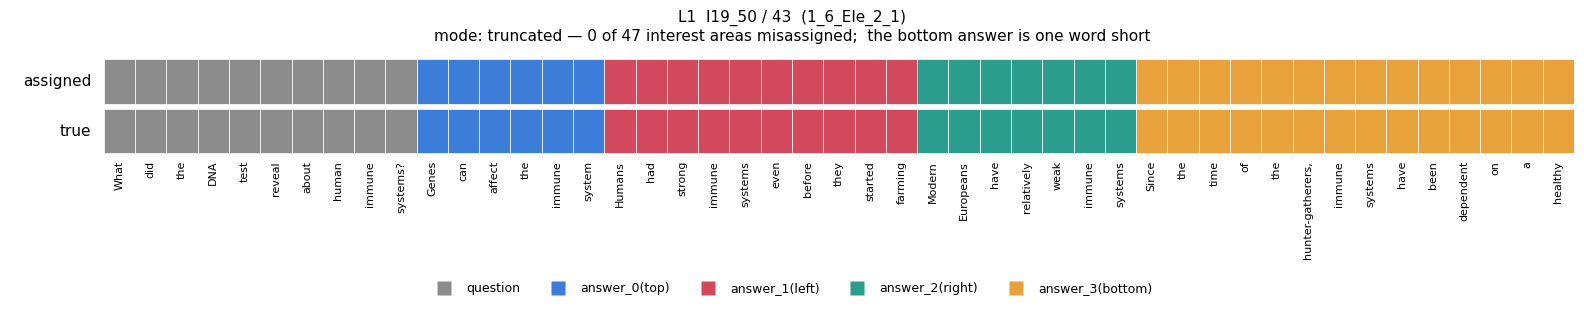

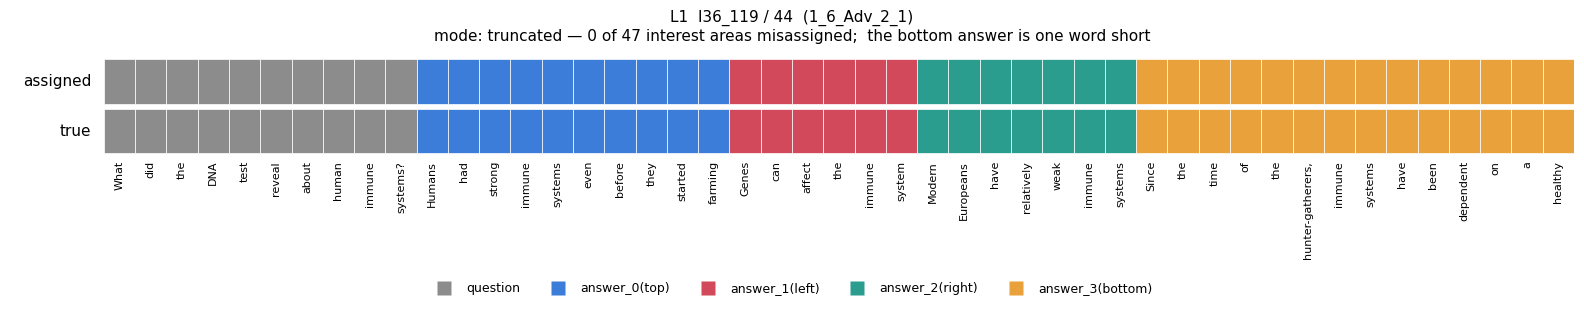

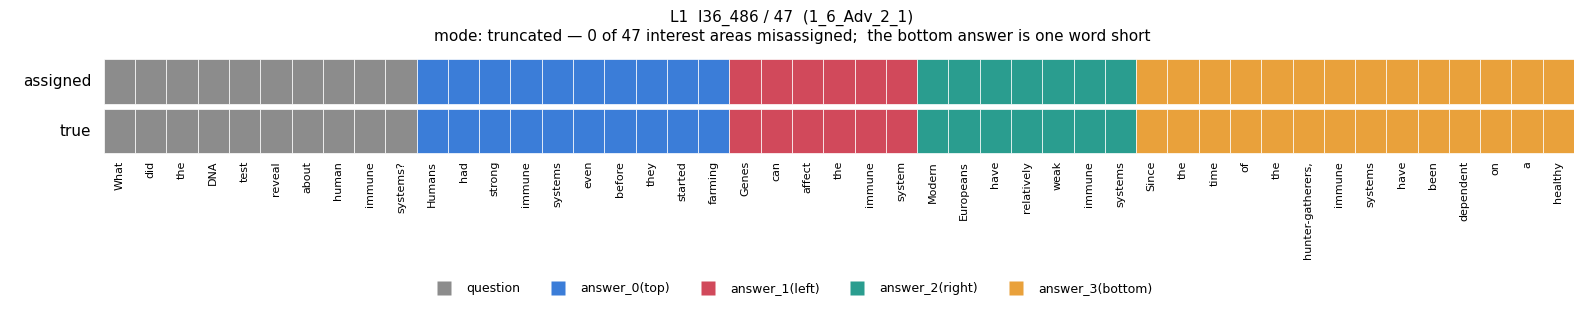

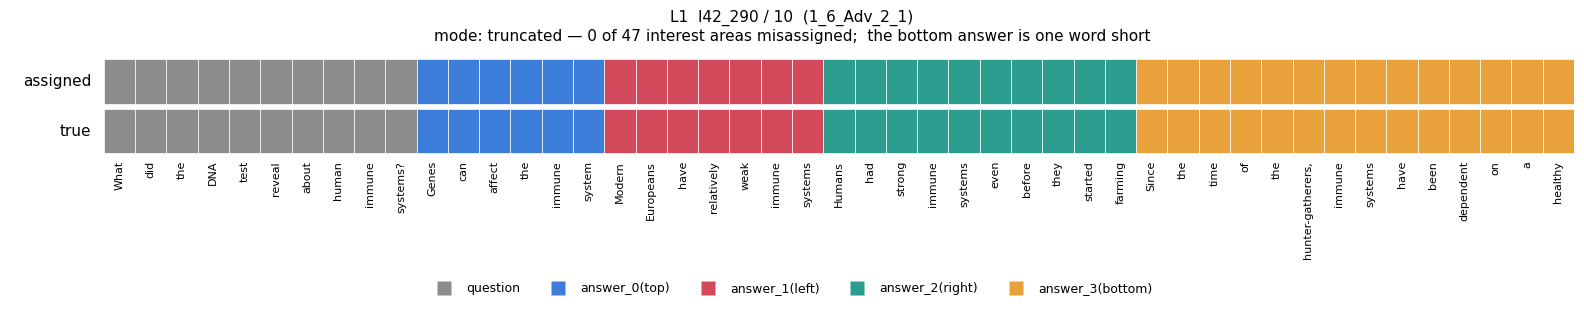

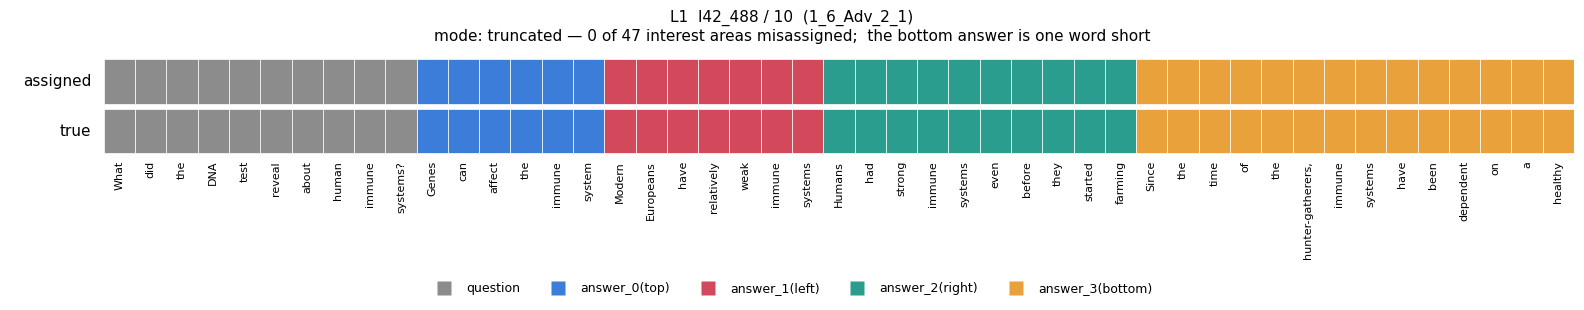

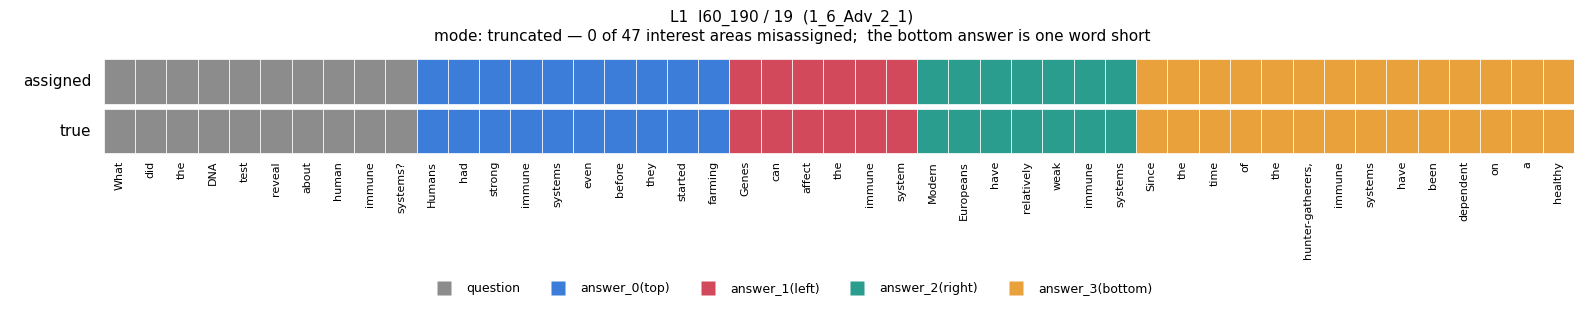

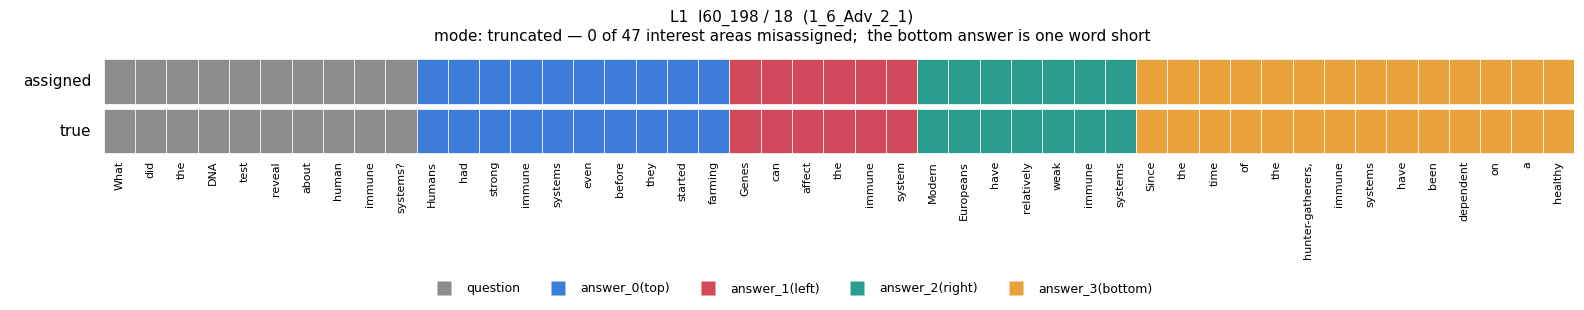

In [18]:
for d in [d for d in gallery if d["mode"] == "truncated"]:
    plot_alignment(
        d["words"], d["assigned"], d["true"],
        f'{d["dataset"]}  {d["trial"]}  ({d["item"]})',
        f'mode: truncated — {d["n_misassigned"]} of {d["n_interest_areas"]} interest areas '
        "misassigned;  the bottom answer is one word short",
        filename=safe_name(f'{d["dataset"]}__{d["trial"]}'),
    )

### 7c. `reordered` — an answer was rendered before the question

L1, items `3_5_Adv_4_1` and `3_5_Ele_3_2`. These are the damaging ones: question words are
scored as answer text and vice versa, so **every per-area metric on these trials is
meaningless**, not merely off by one word.

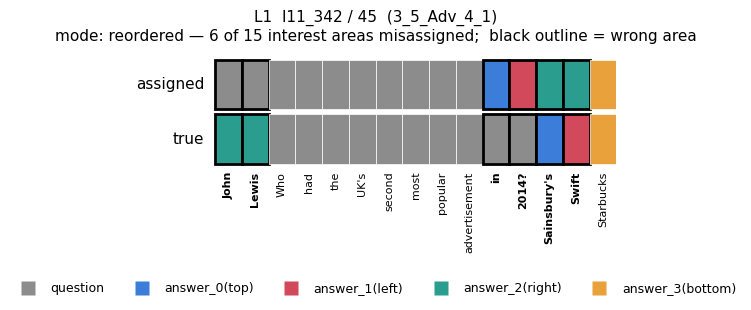

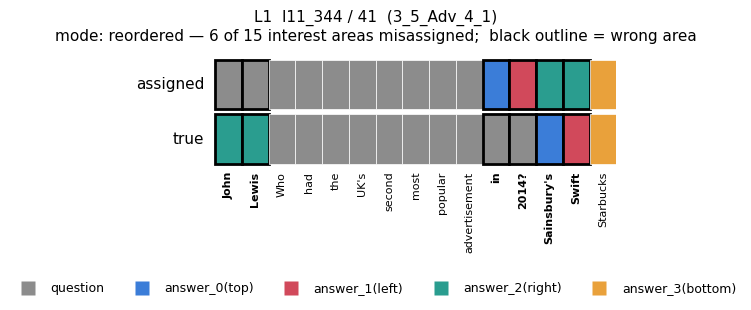

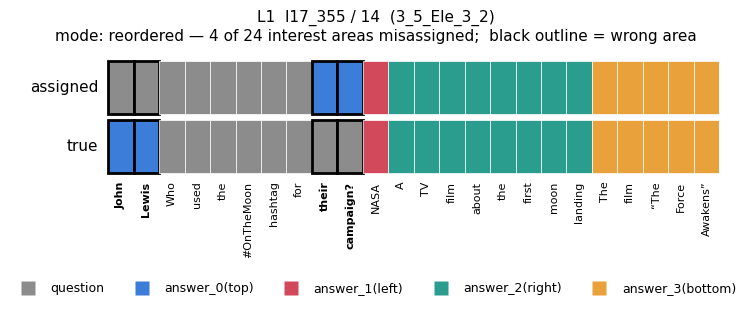

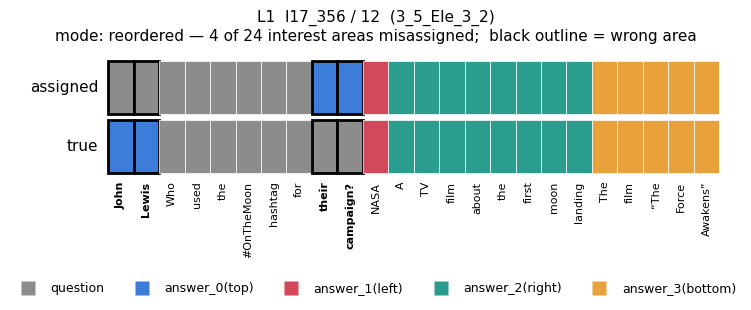

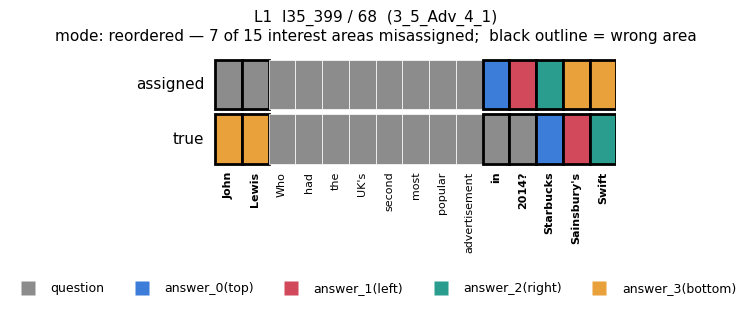

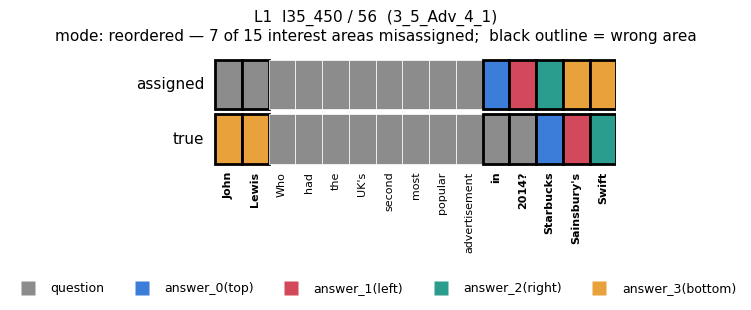

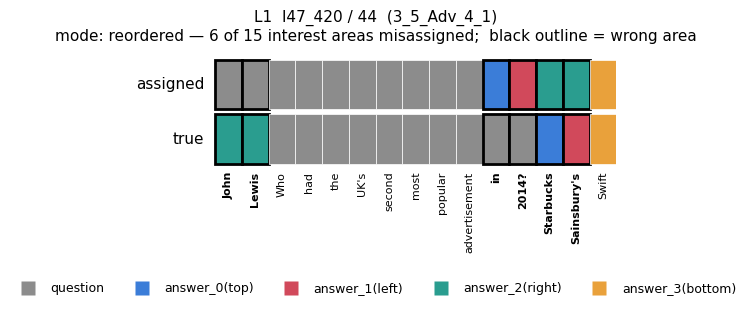

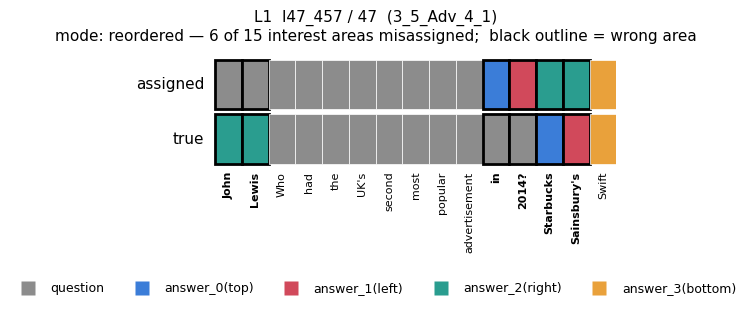

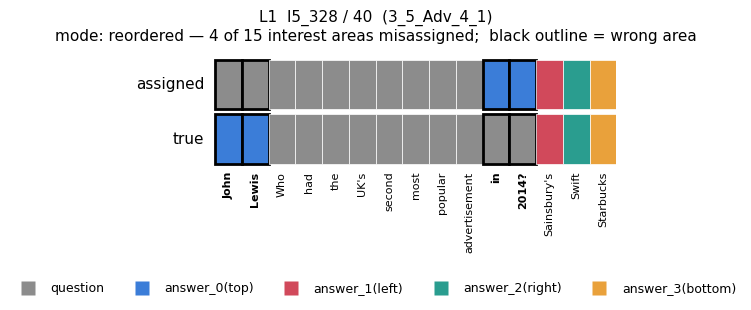

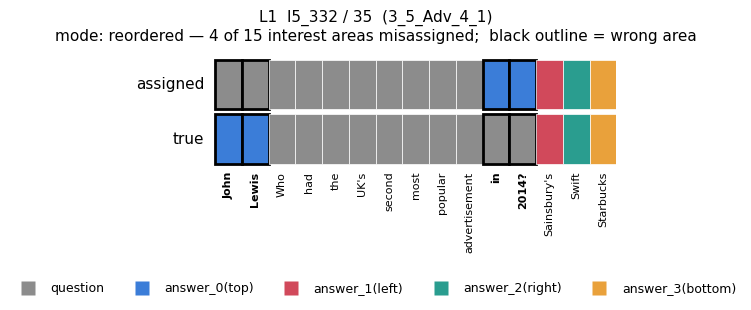

In [19]:
for d in [d for d in gallery if d["mode"] == "reordered"]:
    plot_alignment(
        d["words"], d["assigned"], d["true"],
        f'{d["dataset"]}  {d["trial"]}  ({d["item"]})',
        f'mode: reordered — {d["n_misassigned"]} of {d["n_interest_areas"]} interest areas '
        "misassigned;  black outline = wrong area",
        filename=safe_name(f'{d["dataset"]}__{d["trial"]}'),
    )

---
## 8. Where the extra token comes from

Not from anything in this repository.

In [20]:
ITEM = "3_7_Adv_5_0"

stim = pd.read_csv(P.TEXTS_NO_REPHRASALS_PATH, low_memory=False)
adv = pd.read_csv(P.EXPERIMENT_DIR / "adv_texts_with_ids.csv", low_memory=False)

for name, frame in [("texts_no_rephrasals.csv", stim), ("adv_texts_with_ids.csv", adv)]:
    q = frame.loc[frame.text_id_with_q == ITEM, "question"].iloc[0]
    print(f"{name:26s} {len(str(q).split())} tokens  {q!r}")

raw = pd.read_csv(P.KNOW_QA_CSV_DIR / "IA_answers.csv", usecols=["question"], low_memory=False)
hit = raw.loc[raw.question.astype(str).str.contains("cool", na=False), "question"].iloc[0]
print(f"{'raw KnowQA recording':26s} {len(str(hit).split())} tokens  {hit!r}")

texts_no_rephrasals.csv    8 tokens  'What is true of the English word “cool”?'
adv_texts_with_ids.csv     8 tokens  'What is true of the English word "cool"?'
raw KnowQA recording       9 tokens  'What is true of the English word "cool" "?"'


The stimulus sources hold the question as **one** token (`“cool”?` / `"cool"?`). The **raw
recording already has it split in two** — before any code in this repository touches it. The
experiment presentation software introduced it when writing the trial variable back to the
tracker, and that software is not in this repo (`docs/research-context.md` §4).

So it cannot be fixed here — only detected here, and repaired after the fact.

### The at-risk set is knowable in advance

In [21]:
ends_with_quoted_term = re.compile(r'["\u201d]\?\s*$')
risky = stim[[bool(ends_with_quoted_term.search(str(q))) for q in stim.question]]

print(f'stimulus questions ending  ..."term"?  :  {len(risky)} of {len(stim)}'
      f'  ({100 * len(risky) / len(stim):.1f}%)\n')
print(risky[["text_id_with_q", "question"]].to_string(index=False))

stimulus questions ending  ..."term"?  :  12 of 978  (1.2%)

text_id_with_q                                                                   question
  1_10_Adv_3_1                                      What is the upcoming “bigger crisis”?
  1_10_Ele_3_1                                      What is the upcoming “bigger crisis”?
   2_1_Adv_4_1                                       What does Laura say is “satisfying”?
   2_1_Ele_4_1                                       What does Laura say is “satisfying”?
   3_3_Adv_3_0 According to Duncan Wise, what do people normally consider as “landscape”?
   3_3_Ele_3_0 According to Duncan Wise, what do people normally consider as “landscape”?
   3_6_Adv_7_2               According to Pizzi, what is one benefit of the “cargo bike”?
   3_6_Ele_7_2               According to Pizzi, what is one benefit of the “cargo bike”?
   3_7_Adv_5_0                                   What is true of the English word “cool”?
   3_7_Ele_5_0                         

In [22]:
risky_ids = set(risky.text_id_with_q)

# Every Study 2 trial the check flagged, and whether its question is on the at-risk list.
study2 = misaligned[misaligned.dataset.isin(["KnowQA", "second_test", "testrun_QA"])]
observed = sorted({str(i) for i in study2["item"].dropna()})
print("Study 2 items observed misaligned:")
for i in observed:
    print(f"   {i:16s} on the at-risk list: {i in risky_ids}")

collected = set(knowqa[Con.TEXT_ID_WITH_Q_COLUMN].astype(str).unique())
print()
print(f"KnowQA items collected so far      : {len(collected)}")
print(f"of which on the at-risk list       : {len(collected & risky_ids)}")
print(f"expected rate as collection scales : {100 * len(risky) / len(stim):.1f}% of trials")

Study 2 items observed misaligned:
   2_1_Adv_4_1      on the at-risk list: True
   3_6_Adv_7_2      on the at-risk list: True
   3_7_Adv_5_0      on the at-risk list: True
   3_9_Adv_1_2      on the at-risk list: True

KnowQA items collected so far      : 154
of which on the at-risk list       : 1
expected rate as collection scales : 1.2% of trials


---
## 9. Persist the numbers

`todo.md` T4.0: a figure is a rendering, not a record. Both folders carry the same topic name so
the acceptance test (`reports/plots/<topic>` has a `reports/report_data/<topic>` sibling) holds.
Nothing is mirrored into `papers/`.

In [23]:
if SAVE:
    for frame, name in [
        (misaligned, "misaligned_trials"),
        (per_trial, "per_trial_misassignment"),
        (summary.reset_index().rename(columns={"index": "dataset"}), "summary_by_dataset"),
        (trigger.reset_index(), "tail_truncation_trigger"),
        (risky[["text_id_with_q", "question"]], "at_risk_stimulus_questions"),
        (comparison, "knowqa_trial_area_assignment"),
    ]:
        print(save_df_csv(frame, rel_dir=REL_DIR, filename=name))
    print(f"\nper-trial figures: reports/plots/{TRIAL_REL_DIR.split('/', 1)[1]}/  "
          f"({len(gallery)} files)")
else:
    print("SAVE = False; nothing written")

['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\report_data\\text_alignment\\misaligned_trials.csv']
['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\report_data\\text_alignment\\per_trial_misassignment.csv']
['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\report_data\\text_alignment\\summary_by_dataset.csv']
['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\report_data\\text_alignment\\tail_truncation_trigger.csv']
['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\report_data\\text_alignment\\at_risk_stimulus_questions.csv']
['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\report_data\\text_alignment\\knowqa_trial_area_assignment.csv']

per-trial figures: reports/plots/trials/  (27 files)


---
## 10. Where this leaves T3.18

**Answering the item's own questions.**

| T3.18 asks | Answer |
|---|---|
| Does the guard exclude flagged trials? | **No.** `strict=False` is hardcoded and the return value is discarded. Nothing to fix. |
| Is the misalignment real? | **Yes.** 4 of 38 interest areas misassigned on the flagged trial, silently. |
| Is the guard's diagnosis right? | **Yes, for the case it was written from** — but see below. |
| Should flagged trials be repaired rather than dropped? | Repair is possible: §7 recovers the true area of every interest area in all 27 trials, so nothing needs discarding. |

**What the investigation adds.**

- The guard is a **symptom detector, not a cause detector**. Three causes produce "sequences do
  not match", and §7 shows they are not equally serious: `reordered` misassigns 27–47% of a
  trial's interest areas, `merged` exactly four per trial (9–13%), and `truncated` **none at
  all**. The guard's warning text asserts the `merged` reading for all three.
- It **cannot run on L1 or the pilots** as written, because it groups by KnowQA's identity
  columns — even though those datasets carry every column it needs.
- **L1 has 10 trials whose area labels are structurally wrong** (§7c). At 0.05% of 19,436 trials
  nothing headline moves, but they currently feed every per-area metric.
- `add_IA_screen_location` derives area membership by counting words in a stored string, while
  the reports carry `IA_LEFT` / `IA_RIGHT` / `IA_TOP` / `IA_BOTTOM` for every interest area —
  the ground truth is already in the data. That coupling is what makes this class of bug
  possible, and is worth having in view when **T6.1** reshapes ingest.

**Not investigated here:** how far the ten reordered L1 trials distort their own metrics, and
whether the paragraph screens carry the same class of problem.

**Nothing in this notebook changes the pipeline.** Any repair, any change to the guard, and any
decision about the twenty L1 trials is Diana's.